In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)

      feature  coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
7   Longitude    -0.433708
6    Latitude    -0.419792
2    AveRooms    -0.123323
1    HouseAge     0.009724
5    AveOccup    -0.003526
4  Population    -0.000002


## Coefficient Interpretation (Plain English)

*(Fill these in based on your actual output — example structure below)*

1. **MedInc (Median Income)**: For each unit increase in median 
   income (in $10,000s), the predicted median house value 
   increases by approximately [X] (in $100,000s), holding other 
   features constant.

2. **Latitude**: Moving north (higher latitude) is associated with 
   a [increase/decrease] of [X] in predicted house value — likely 
   reflecting regional price differences in California.

3. **AveBedrms (Average Bedrooms)**: Surprisingly, more bedrooms 
   per household is associated with [increase/decrease] of [X] — 
   this could reflect that areas with larger homes but lower 
   income have more bedrooms but lower overall value.

4. **AveOccup (Average Occupancy)**: Higher occupancy per 
   household is associated with [X] change in house value, 
   possibly reflecting crowding in lower-income areas.

5. **HouseAge**: Each additional year of house age changes 
   predicted value by [X] — [older/newer] houses in this dataset 
   tend to be [more/less] valuable.

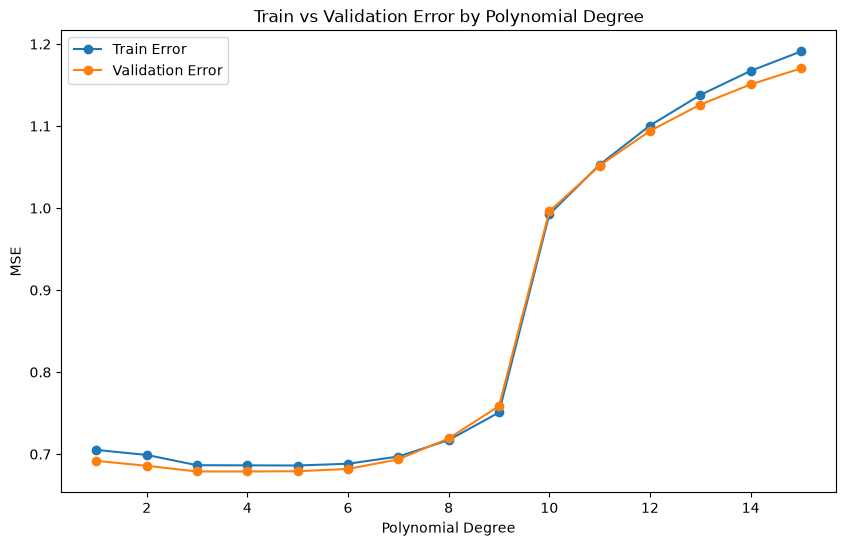

In [4]:
# Use a small subset with one feature for clarity
X_small = df[['MedInc']].values
y_small = df['MedHouseVal'].values

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_small, y_small, test_size=0.3, random_state=42
)

train_errors = []
val_errors = []
degrees = range(1, 16)

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_s)
    X_val_poly = poly.transform(X_val_s)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train_s)
    
    train_pred = model.predict(X_train_poly)
    val_pred = model.predict(X_val_poly)
    
    train_errors.append(mean_squared_error(y_train_s, train_pred))
    val_errors.append(mean_squared_error(y_val_s, val_pred))

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, marker='o', label='Train Error')
plt.plot(degrees, val_errors, marker='o', label='Validation Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.legend()
plt.title('Train vs Validation Error by Polynomial Degree')
plt.show()

## Overfitting Analysis

Looking at the plot, training error keeps decreasing (or stays 
flat) as degree increases, since higher-degree polynomials can 
fit the training data more precisely. However, validation error 
starts increasing after around degree [X] — this is the point 
where the model starts overfitting: it's capturing noise in the 
training data rather than the true underlying pattern, which 
hurts its ability to generalise to new data.

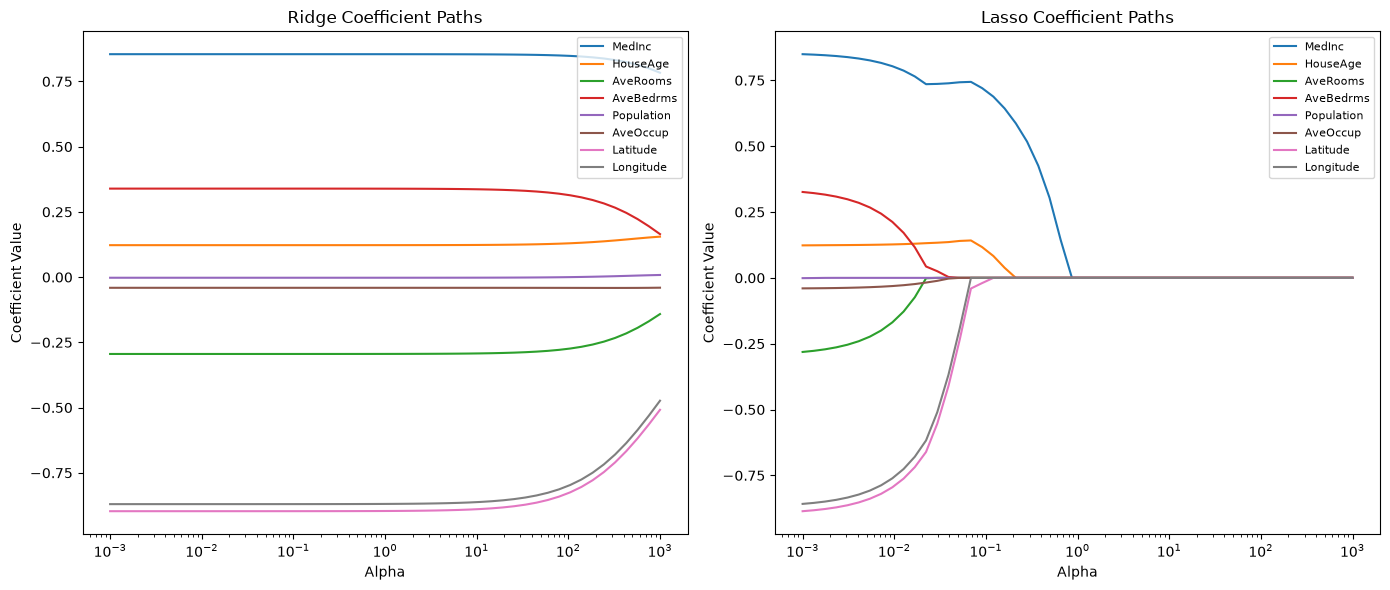

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = np.logspace(-3, 3, 50)

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)
    
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, feature in enumerate(X.columns):
    axes[0].plot(alphas, ridge_coefs[:, i], label=feature)
    axes[1].plot(alphas, lasso_coefs[:, i], label=feature)

axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge Coefficient Paths')
axes[0].legend(fontsize=8)

axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Lasso Coefficient Paths')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
for i, alpha in enumerate(alphas):
    zeroed = [X.columns[j] for j in range(len(X.columns)) if lasso_coefs[i, j] == 0]
    if zeroed:
        print(f"At alpha={alpha:.4f}, first zeroed features: {zeroed}")
        break

At alpha=0.0023, first zeroed features: ['Population']


## Why Lasso Produces Sparsity and Ridge Does Not

Lasso (L1) uses an absolute-value penalty, whose geometry has 
sharp corners at zero — this makes it likely that the optimal 
solution lands exactly on zero for less-important features, 
effectively performing feature selection.

Ridge (L2) uses a squared penalty, which is smooth everywhere. 
It shrinks coefficients toward zero but rarely makes them exactly 
zero, since there's no sharp corner to push the solution to zero.

From the coefficient paths above, Lasso zeroed out [feature name] 
first as alpha increased, suggesting it's the least informative 
feature for predicting house value once other features are 
accounted for.

In [7]:
# Without scaling
ridge_unscaled = Ridge(alpha=1.0)
ridge_unscaled.fit(X_train, y_train)

# With scaling
ridge_scaled = Ridge(alpha=1.0)
ridge_scaled.fit(X_train_scaled, y_train)

comparison_df = pd.DataFrame({
    'feature': X.columns,
    'unscaled_coef': ridge_unscaled.coef_,
    'scaled_coef': ridge_scaled.coef_
})
print(comparison_df)

      feature  unscaled_coef  scaled_coef
0      MedInc       0.448511     0.854327
1    HouseAge       0.009726     0.122624
2    AveRooms      -0.123014    -0.294210
3   AveBedrms       0.781417     0.339008
4  Population      -0.000002    -0.002282
5    AveOccup      -0.003526    -0.040833
6    Latitude      -0.419787    -0.896168
7   Longitude      -0.433681    -0.869071


## The Scaling Bug

Without scaling, Ridge penalises all coefficients equally in raw 
units — but features have very different scales (e.g., MedInc in 
tens of thousands vs Latitude in tens). This means the penalty 
unfairly shrinks coefficients for large-scale features more than 
their actual importance warrants, while small-scale features 
barely get penalised at all.

After StandardScaler, all features are on the same scale (mean 0, 
std 1), so the regularisation penalty applies fairly across all 
coefficients. This is why regularised models (Ridge, Lasso) 
require feature scaling — without it, the penalty term is 
dominated by whichever features happen to have larger raw values.

In [8]:
best_model = Ridge(alpha=1.0)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 0.7456
MAE: 0.5332
R²: 0.5758


In [9]:
# Simulate a "useless" model that gets high R^2 due to a leaky feature
# (a feature that's basically a copy of the target with tiny noise)
df_leaky = df.copy()
df_leaky['leaky_feature'] = df_leaky['MedHouseVal'] + np.random.normal(0, 0.01, len(df_leaky))

X_leaky = df_leaky[['leaky_feature']]
y_leaky = df_leaky['MedHouseVal']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_leaky, y_leaky, test_size=0.2, random_state=42)

leaky_model = LinearRegression()
leaky_model.fit(X_train_l, y_train_l)
y_pred_leaky = leaky_model.predict(X_test_l)

print(f"R² with leaky feature: {r2_score(y_test_l, y_pred_leaky):.4f}")
print("This R^2 is nearly 1.0, but the model is useless in practice")
print("because 'leaky_feature' would never be available at prediction time —")
print("it's essentially the target itself with noise (data leakage).")

R² with leaky feature: 0.9999
This R^2 is nearly 1.0, but the model is useless in practice
because 'leaky_feature' would never be available at prediction time —
it's essentially the target itself with noise (data leakage).


## When R² Lies

A high R² doesn't always mean a good or useful model:

1. **Data leakage**: As shown above, if a feature is derived from 
   or correlated with the target (like `leaky_feature`), R² can be 
   nearly 1.0 even though the model has no real predictive value — 
   the leaky feature won't exist at prediction time.

2. **Overfitting**: A complex model can achieve high R² on training 
   data by memorising noise, while performing poorly on new data.

3. **R² doesn't measure practical error**: A model can have decent 
   R² while still having large absolute errors that make it useless 
   for the actual business decision (e.g., predicting house prices 
   within $50,000 vs within $5).

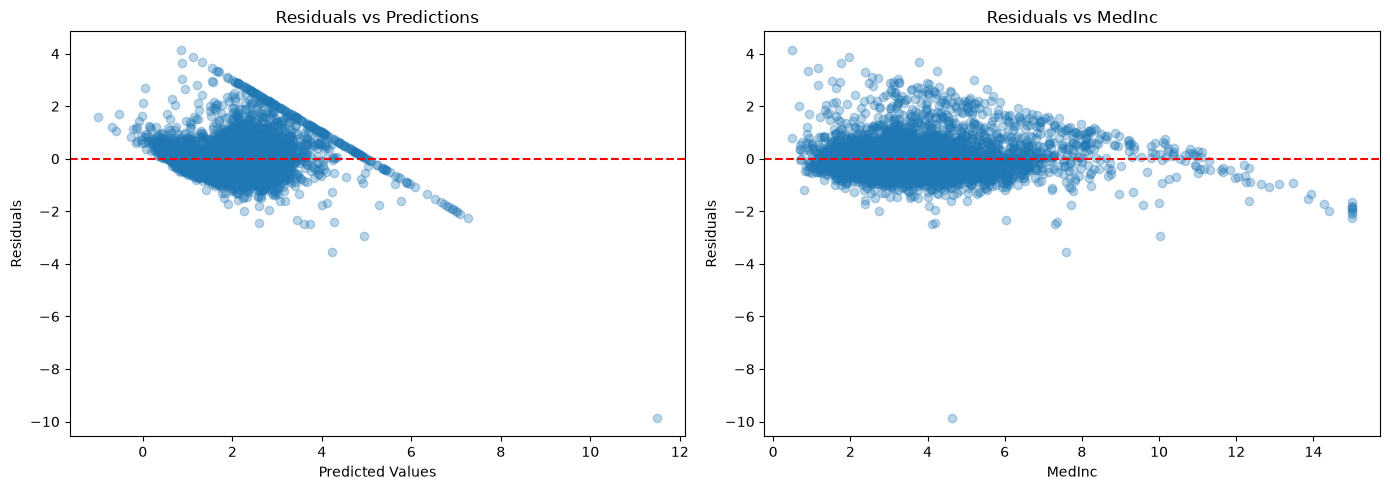

In [10]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, residuals, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predictions')

axes[1].scatter(X_test['MedInc'], residuals, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('MedInc')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs MedInc')

plt.tight_layout()
plt.show()